In [14]:
import pandas as pd
import matplotlib.pyplot as plt 

In [15]:
datos_limpios= pd.read_pickle('../data/datos_arbolado')

In [16]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340147 entries, 0 to 370055
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   340147 non-null  float64
 1   lat                    340147 non-null  float64
 2   comuna                 340147 non-null  float64
 3   manzana                205444 non-null  object 
 4   calle_nombre           340147 non-null  object 
 5   calle_altura           340147 non-null  int64  
 6   calle_chapa            336784 non-null  Int32  
 7   nombre_cientifico      340147 non-null  object 
 8   ancho_acera            340147 non-null  float64
 9   estado_plantera        339998 non-null  float64
 10  ubicacion_plantera     339288 non-null  object 
 11  nivel_plantera         339478 non-null  float64
 12  diametro_altura_pecho  340147 non-null  float64
 13  altura_arbol           338991 non-null  float64
dtypes: Int32(1), float64(8), int64(1), object

In [17]:
datos_limpios=datos_limpios[datos_limpios['altura_arbol'].notna()]

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer # Para rellenar nulos

# 1. Seleccionar features y limpiar nulos
features_quant = ['ancho_acera', 'diametro_altura_pecho', 'altura_arbol', 'estado_plantera', 'nivel_plantera']
df_quant = datos_limpios[features_quant].copy()

# Rellenamos los nulos de altura (el clustering no acepta nulos)
imputer = SimpleImputer(strategy='median')
df_quant_imputed = imputer.fit_transform(df_quant)

# 2. Estandarizar los datos (¡EL PASO MÁS IMPORTANTE!)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_quant_imputed)

# 3. Correr K-Means (ej. buscando 4 "tipos" de árboles)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# 4. Asignar los "tipos" de árbol de vuelta al DataFrame
datos_limpios['cluster_fenotipo'] = kmeans.labels_

# 5. Entender los clústeres
# (Invierte la escala para ver los centros en metros y cm)
centros = scaler.inverse_transform(kmeans.cluster_centers_)
df_centros = pd.DataFrame(centros, columns=features_quant)
print("Centros de los Clústeres (en unidades originales):")
print(df_centros)

Centros de los Clústeres (en unidades originales):
   ancho_acera  diametro_altura_pecho  altura_arbol  estado_plantera  \
0     3.881929              60.804715     15.214390         2.006327   
1     4.545259              25.983122      7.119985         1.999300   
2     3.865045              25.938661      7.058600         3.000000   
3     2.880467              24.170239      7.691224         1.999228   

   nivel_plantera  
0        0.984107  
1        1.127664  
2        1.427644  
3        1.094101  


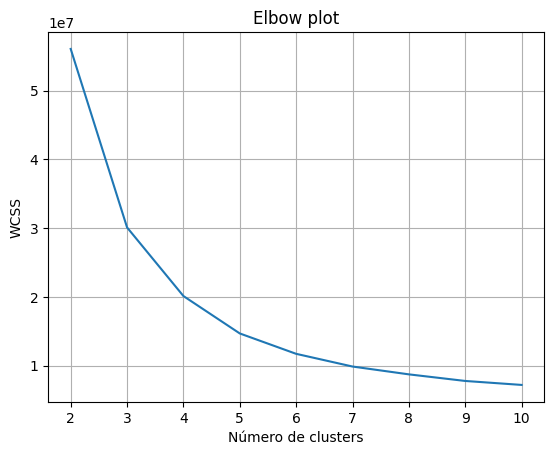

In [19]:
from sklearn.cluster import KMeans

# calculamos cada KMean para cada número de clusters, y nos quedamos con el valor
wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=10)
    kmeans.fit(df_quant)
    wcss.append(kmeans.inertia_)

# graficamos el elbow plot
plt.plot(range(2, 11), wcss)
plt.title('Elbow plot')
plt.grid("True")
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

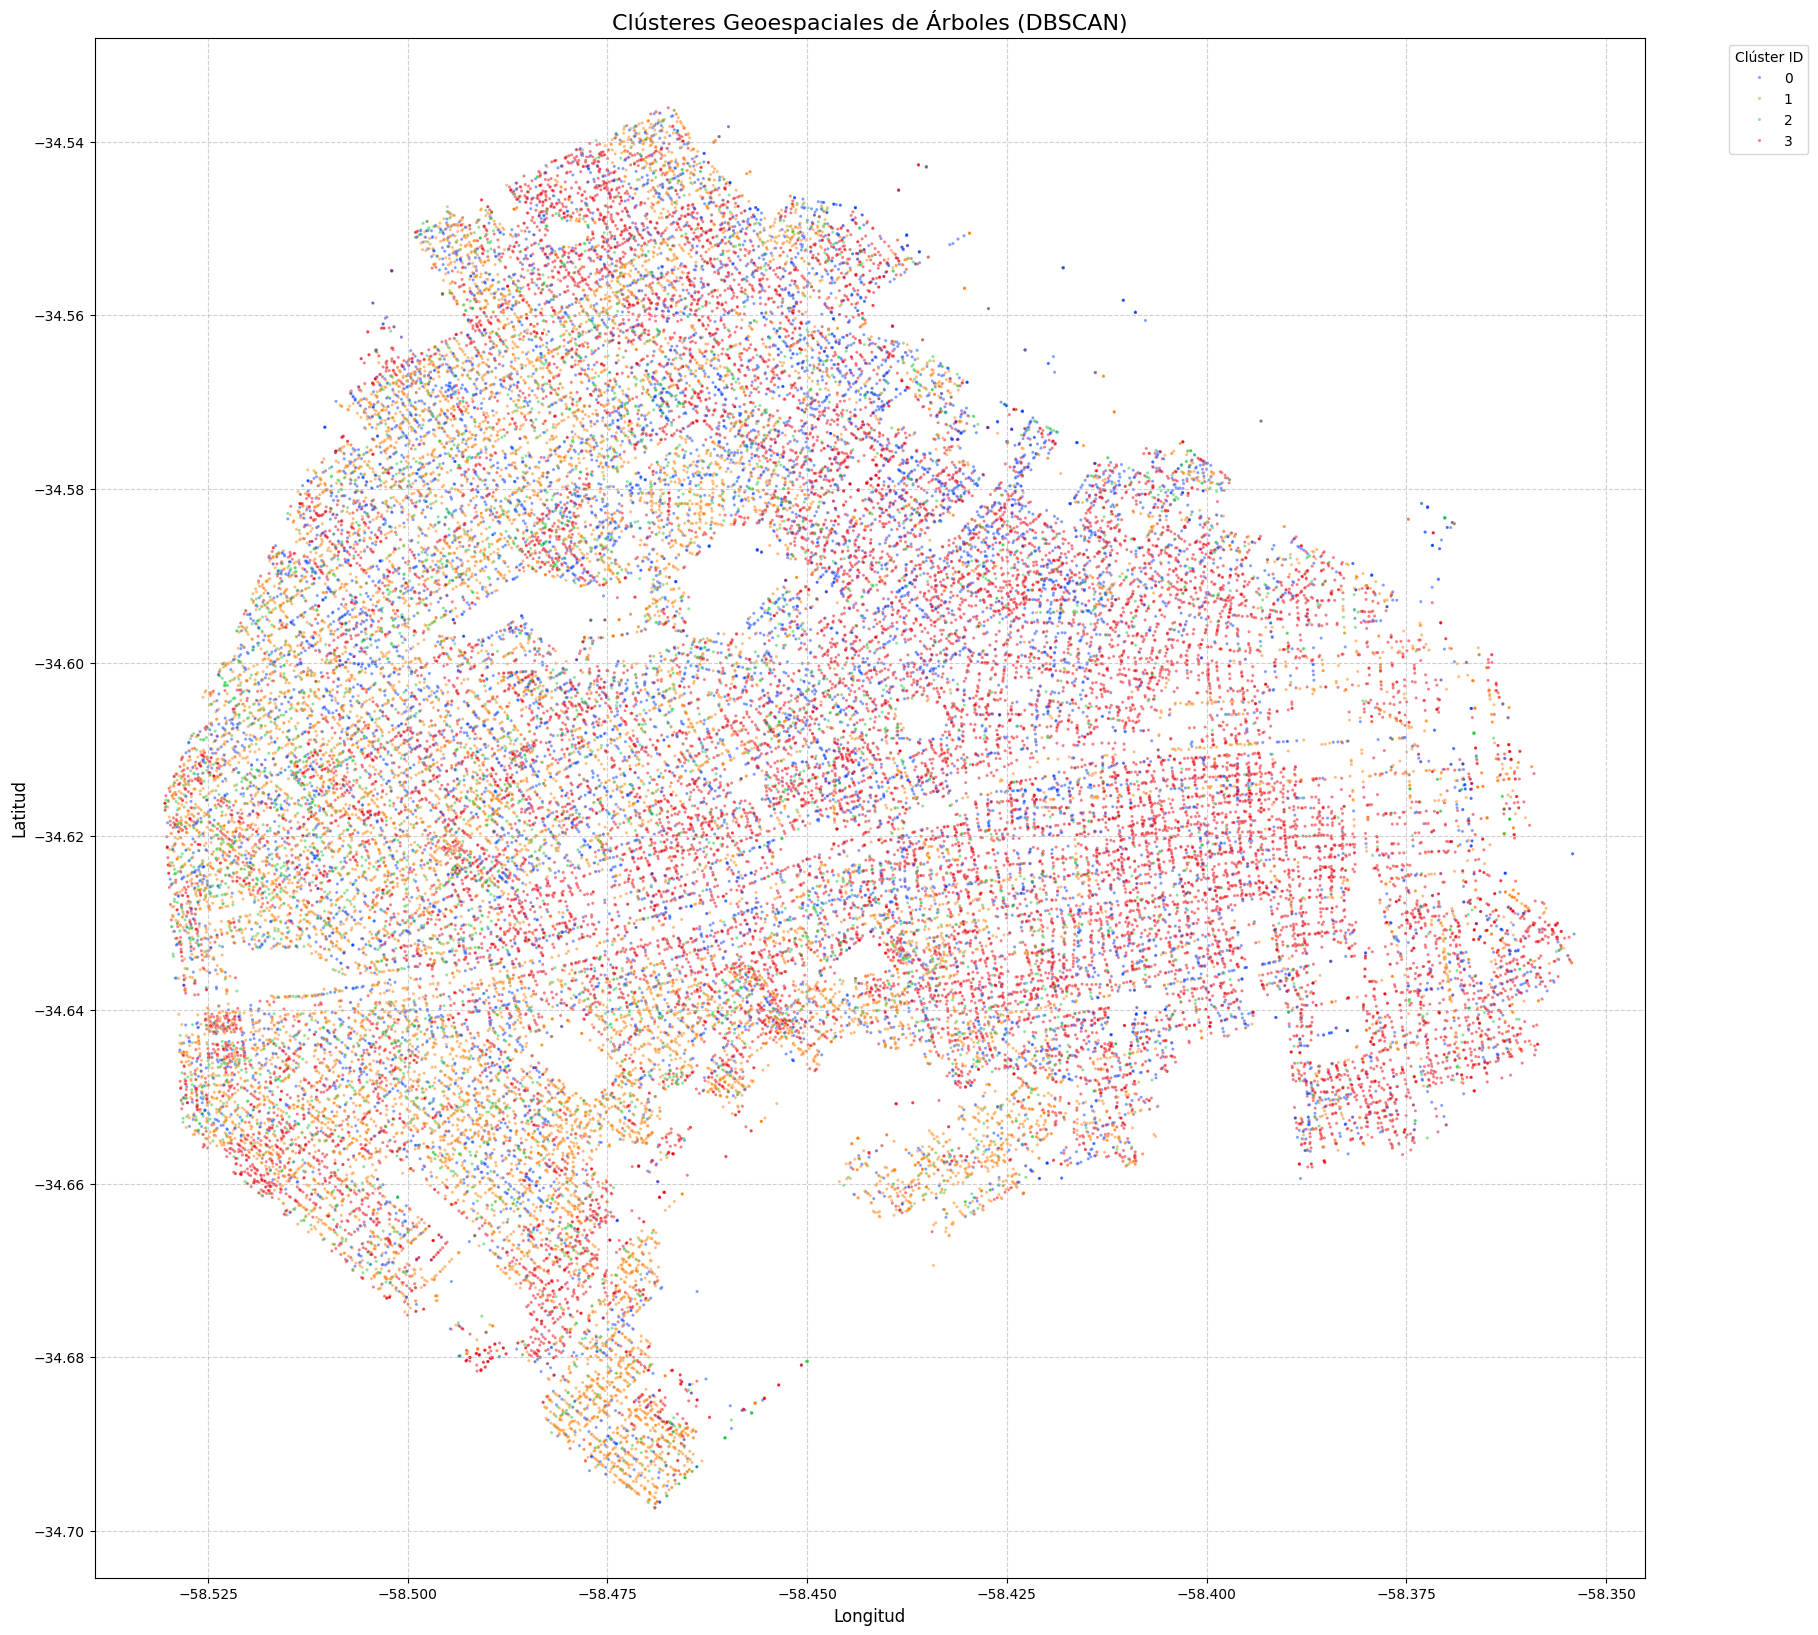

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tomamos una muestra aleatoria (ej. 50,000 puntos) para que el gráfico sea legible
# (Asumo que tu DataFrame se llama 'datos_arbolado' y ya tiene la columna 'cluster_espacial')
df_sample_geo = datos_limpios.sample(n=min(50000, len(datos_limpios)), random_state=42)

# 2. Creamos el scatter plot con Seaborn
plt.figure(figsize=(20, 20))
sns.scatterplot(
    data=df_sample_geo,
    x='long',
    y='lat',
    hue='cluster_fenotipo', # ¡Aquí está la magia!
    palette='bright',         # Paleta de colores vivos
    s=5,                    # Tamaño de punto pequeño
    alpha=0.5,              # Transparencia
    legend='full'
)

plt.title('Clústeres Geoespaciales de Árboles (DBSCAN)', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(title='Clúster ID', bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Analisis por especies en los cluster

In [29]:
# (Tu código de K-Means... ya lo tienes)
# ...
# Esto te da la columna 'cluster_fenotipo'
datos_limpios['cluster_fenotipo'] = kmeans.labels_

In [30]:
# Analicemos la composición de especies de cada clúster
conteo_especies_por_cluster = datos_limpios.groupby('cluster_fenotipo')['nombre_cientifico'].value_counts()

print(conteo_especies_por_cluster)

cluster_fenotipo  nombre_cientifico     
0                 Platanus x acerifolia     24825
                  Fraxinus pennsylvanica    19022
                  Melia azedarach            7805
                  Otra                       6630
                  Tipuana tipu               5420
                  Ficus benjamina            3268
                  Fraxinus americana         1476
                  Jacaranda mimosifolia      1414
                  Tilia x moltkei            1361
                  Fraxinus excelsior          908
                  Ligustrum lucidum           161
                  Lagerstroemia indica         32
1                 Fraxinus pennsylvanica    36980
                  Otra                      24764
                  Tilia x moltkei            6578
                  Ficus benjamina            6313
                  Jacaranda mimosifolia      5132
                  Lagerstroemia indica       3874
                  Ligustrum lucidum          3611
         

/tmp/ipykernel_25270/390734943.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'conteo')) \


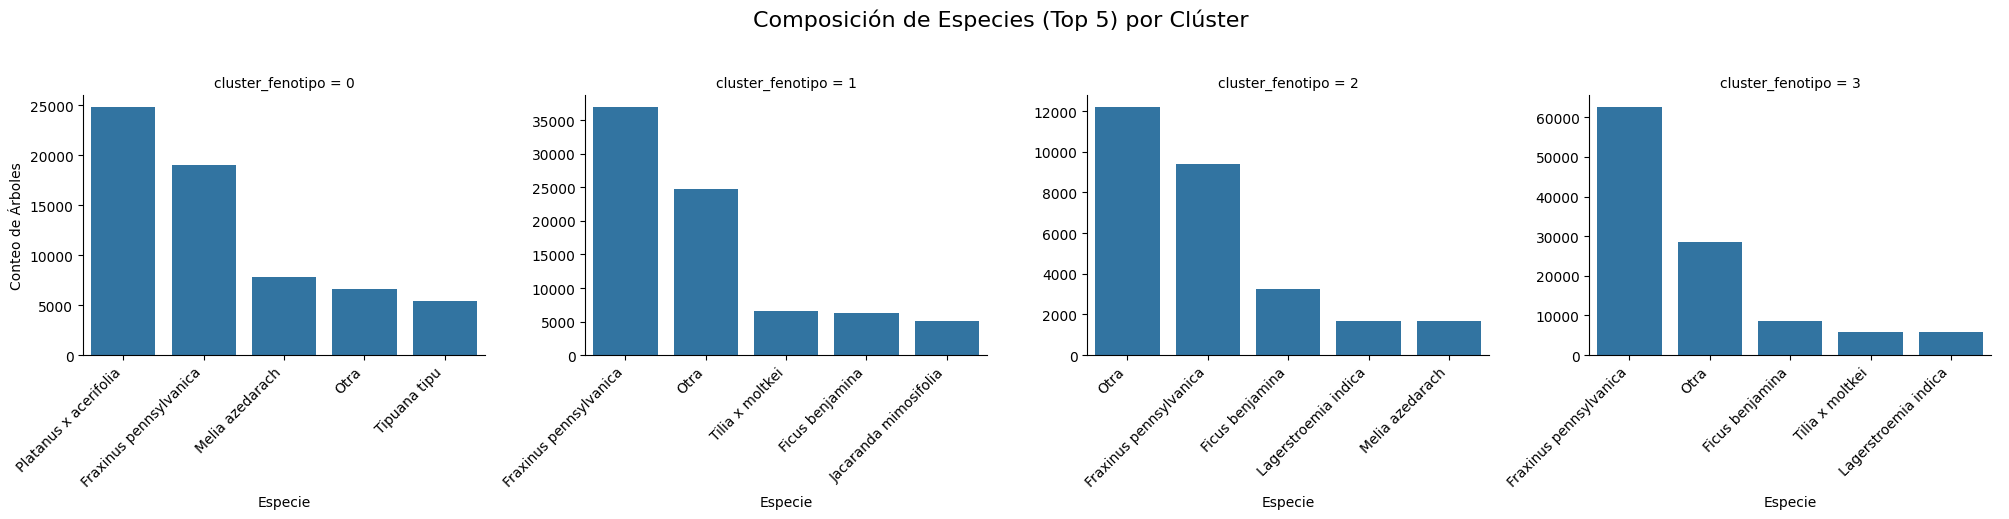

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. (Si aún no lo tienes) Convierte tu Serie MultiIndex en un DataFrame
conteo_series = datos_limpios.groupby('cluster_fenotipo')['nombre_cientifico'].value_counts()
df_conteo = conteo_series.reset_index(name='conteo')

# 2. Filtramos para quedarnos solo con el "Top 5" de especies de CADA clúster
#    Esto es clave para que el gráfico sea legible.
df_top5_por_cluster = df_conteo.groupby('cluster_fenotipo') \
                                  .apply(lambda x: x.nlargest(5, 'conteo')) \
                                  .reset_index(drop=True)

# 3. ¡Graficamos! Usamos seaborn.catplot
g = sns.catplot(
    data=df_top5_por_cluster,
    x='nombre_cientifico',  # Eje X: Las especies
    y='conteo',             # Eje Y: Cuántos hay
    col='cluster_fenotipo', # <-- ¡La Magia! Crea un gráfico por clúster
    kind='bar',             # Tipo de gráfico: barras
    sharey=False,           # Cada gráfico tendrá su propia escala Y (importante)
    sharex=False            # Cada gráfico tendrá sus propias etiquetas X
)

# 4. Ajustamos las etiquetas para que sean legibles
g.fig.suptitle('Composición de Especies (Top 5) por Clúster', y=1.03, fontsize=16)
g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels('Especie', 'Conteo de Árboles')

plt.tight_layout()
plt.show()

* **Clúster 0: "Los Gigantes Maduros"**
    * Este clúster se define inequívocamente por su tamaño. Es el grupo de los árboles más grandes y maduros de tu dataset (probablemente los Plátanos y otras especies viejas que ya analizamos). Viven en aceras de tamaño decente, lo que les ha permitido crecer.
* **Clúster 1: "Los Privilegiados de Avenida"**
    * Este grupo es de tamaño "estándar", pero lo que lo hace único es el enorme ancho de acera del que disfruta. Estos son árboles de tamaño mediano plantados en las mejores condiciones: avenidas, bulevares o aceras muy anchas, donde tienen espacio de sobra.
* **Clúster 2: "Los Problemáticos de Plantera"**
    * Este clúster tiene un tamaño idéntico al Clúster 1, pero el algoritmo los separó por una razón: su entorno de plantación es malo. Suponiendo que números más altos son peores (ej. 3='Mala', 1.42='Muy Elevada/Rota'), este clúster identifica a los árboles de tamaño mediano que están en las planteras en peor estado.
* **Clúster 3: "Los Estresados de Vereda"**
    * El algoritmo identificó a todos los árboles de tamaño mediano que están "apretados" en las aceras más estrechas. Este es un grupo de riesgo futuro por rotura de veredas y estrés hídrico.